# Matching a pool to an aggregate target

`AggregateConstraintSatisfactionMatcher` selects a subset of a patient-level pool so that its
moments match a target known only through **summary statistics** -- e.g. a published trial's
Table 1 (means, proportions, sometimes standard deviations) -- rather than patient-level rows.

The notebook builds up over three use cases, each disclosing a bit more or something different
about the target:
1. **means only** (plus a categoric proportion);
2. **means and stds**, which adds a variance constraint;
3. **medians and other quantiles instead of means**, plus a soft **max**.

Features the target says nothing about (here `height` and `country`) are not constrained, but we keep
them in the `MatchingData` so we can still see how matching changes them.

The patient-level pool is synthetic (`pybalance.sim.generate_toy_dataset`); no patient-level target
rows are ever used.

In [1]:
import logging

import matplotlib.pyplot as plt
import pandas as pd

from pybalance.lp import AggregateConstraintSatisfactionMatcher
from pybalance.sim import (
    generate_toy_dataset,
    get_demo_aggregate_target_path,
    load_demo_aggregate_target,
)
from pybalance.utils import (
    AggregateTarget,
    MatchingData,
    MatchingHeaders,
    aggregate_target_constraints,
)
from pybalance.visualization import (
    plot_aggregate_target_match,
    plot_fractional_difference,
)

%matplotlib inline

# show the matcher's CP-SAT solver output
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

## 1. A patient-level (synthetic) pool

An aggregate-target match only needs patient-level data for the **pool**. `generate_toy_dataset`
returns an entirely simulated one (no real patients); with `n_target=0` it generates no target
patients at all, since the target will come from summary statistics instead.

In [2]:
m = generate_toy_dataset(n_pool=1000, n_target=0, seed=7)
pool = m.get_population("pool").drop(columns=[m.population_col])
pool.head()

,age,height,weight,gender,haircolor,country,binary_0,binary_1,binary_2,binary_3,patient_id
0,69.436489,155.189260,79.144533,0.0,1,4,0,0,1,1,0
1,28.771438,175.270602,97.734561,1.0,0,5,0,0,1,1,1
2,62.640154,136.648640,85.170055,0.0,1,2,0,0,0,1,2
3,68.907932,189.959952,90.705549,0.0,1,3,0,0,1,1,3
4,49.571169,133.787109,76.708193,1.0,2,3,0,0,0,1,4


## 2. Use case 1 -- specifying means only

An `AggregateTarget` is the target's sample size `n` plus whatever summary statistics are disclosed:

- `numeric`: per feature, e.g. `{"mean": ...}`;
- `categoric`: per feature, `{level: rate}` -- the proportion of each category.

Here the target discloses the mean `age` and `weight` and the proportion of each `gender`.

In [3]:
my_target = AggregateTarget(
    n=250,
    numeric={
        "age": {"mean": 64.0},
        "weight": {"mean": 80.0},
    },
    categoric={"gender": {0: 0.35, 1: 0.65}},
)
my_target

feature,type,stat,value
age,numeric,mean,64.00
weight,numeric,mean,80.00
gender,categoric,0,0.35
gender,categoric,1,0.65


To match, wrap the pool and the target in a `MatchingData` and hand it to
`AggregateConstraintSatisfactionMatcher`, which solves for the subset of the pool whose statistics
come closest to every disclosed constraint.

The `headers` say which pool columns we want to look at. They may include features the target does
not disclose -- here `height` and `country`. Those are left unconstrained by the matcher, but
reported in the results, so we can see what matching does to them.

In [4]:
headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "country"])

matching_data = MatchingData(pool=pool, target=my_target, headers=headers)
matcher = AggregateConstraintSatisfactionMatcher(
    matching_data, time_limit=60, num_workers=1, verbose=True
)
matched = matcher.match()

Scaling features by factor 240.00 in order to use integer solver with <= 0.5782% loss.
Solving for match population with pool size = 250 and target size = 250 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 4 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Solving with 1 workers ...
Initial balance score: 0.3308
Solution 1, time = 0.00 m
Objective:	631500.0
Balance (aggregate_beta):	0.0418
Patients (pool):	250
Patients (target):	250 (aggregate)
 
Solution 2, time = 0.00 m
Objective:	39750.0
Balance (aggregate_beta):	0.0060
Patients (pool):	250
Patients (target):	250 (aggregate)
 
Solution 3, time = 0.01 m
Objective:	32250.0
Balance (aggregate_beta):	0.0058
Patients (pool):	250
Patients (target):	250 (aggregate)
 
Solution 4, time = 0.01 m
Objective:	31750.0
Balance (aggregate_beta):	0.0056
Patients (pool):	250
Patients (target):	250 (aggregate)
 
Solution 5, time = 0.01 m
Ob

`matched` is a new `MatchingData` holding the selected subset. `describe()` puts the original pool,
the matched pool and the target side by side. `age`, `weight` and `gender` move onto their targets;
`height` and `country` have no target (`NaN`), but we can still see how they shifted as a side effect.

In [5]:
(
    matching_data
        .describe(quantiles=[])
        .join(
            matched.describe(quantiles=[]),
            rsuffix='_matched'
        )[['pool', 'pool_matched', 'target']]
)

pool  pool_matched  target
population size N     1000.000       250.000  250.00
gender          0.0      0.483         0.352    0.35
                1.0      0.517         0.648    0.65
country         1.0      0.108         0.112     NaN
                2        0.224         0.232     NaN
                3        0.274         0.288     NaN
                4        0.284         0.268     NaN
                5        0.110         0.100     NaN
age             mean    55.520        64.110   64.00
                std     13.110        10.530     NaN
weight          mean    88.020        80.140   80.00
                std     16.550        16.120     NaN
height          mean   160.310       156.200     NaN
                std     19.500        18.850     NaN

To check just the disclosed constraints, `aggregate_target_constraints` lists each one next to the
value the pool achieves, and `plot_aggregate_target_match` draws it: one panel per constraint, with
the dashed line at the disclosed target, a shaded band around it, and the pool's value before and
after matching. A successful match moves the "after" dot onto the dashed line.

,feature,constraint,target,pool_before,pool_after
0,age,mean,64.00,55.520,64.114
1,weight,mean,80.00,88.017,80.139
2,gender,rate of 0,0.35,0.483,0.352
3,gender,rate of 1,0.65,0.517,0.648


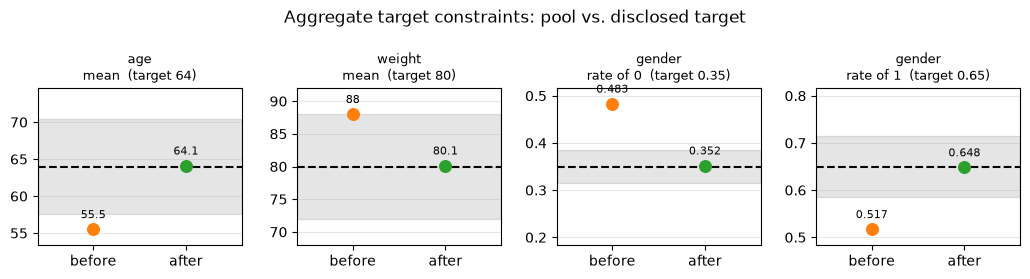

In [6]:
constraints = aggregate_target_constraints(matching_data).merge(
    aggregate_target_constraints(matched),
    on=["feature", "constraint", "target"],
    suffixes=("_before", "_after"),
)
display(constraints.round(3))

fig = plot_aggregate_target_match(matching_data, matched)

## 3. Use case 2 -- adding stds

Now the target also discloses a **std** for each numeric feature. The matcher then constrains each
variance toward its disclosed value, in addition to the mean.

Typing targets out by hand gets long, so `pybalance.sim` ships ready-made ones: summaries of a toy
target population that disclose different amounts of information, to be matched against the pool
above. `load_demo_aggregate_target(use_case)` returns the packaged `AggregateTarget` and
`generate_aggregate_target(use_case)` derives the same thing from the toy dataset -- or from your own
patient-level `MatchingData`, via its `matching_data=` argument.

| `use_case` | disclosed statistics |
|---|---|
| `means` | `age` and `weight` means, `gender` rates (what we wrote by hand above) |
| `means_std` | `age` and `weight` means and stds, `gender` rates |
| `quantiles` | `age` quartiles and `weight` median (instead of means), `gender` rates |

`match_to` repeats the steps from use case 1 -- build a `MatchingData` from the pool and a target,
then run `AggregateConstraintSatisfactionMatcher` -- so each use case below is a couple of lines.

In [7]:
def match_to(target):
    """Match `pool` to an AggregateTarget; returns (matching_data, matched)."""
    matching_data = MatchingData(pool=pool, target=target, headers=headers)
    matcher = AggregateConstraintSatisfactionMatcher(
        matching_data, time_limit=60, num_workers=1, verbose=True
    )
    return matching_data, matcher.match()

Load the `means_std` target and match. Displaying the target shows exactly what it discloses.

In [8]:
target_b = load_demo_aggregate_target("means_std")
display(target_b)
before_b, after_b = match_to(target_b)

feature,type,stat,value
age,numeric,mean,50.795973
age,numeric,std,15.019030
weight,numeric,mean,82.079040
weight,numeric,std,18.721164
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000


Scaling features by factor 240.00 in order to use integer solver with <= 0.5782% loss.
Scaling variance terms by factor 2 (vs. mean-term factor 240.0) so neither dominates the objective purely due to units.
Solving for match population with pool size = 100 and target size = 100 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 4 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Applying variance constraints on 2 feature(s) with disclosed std ...
Solving with 1 workers ...
Initial balance score: 0.1899
Solution 1, time = 0.00 m
Objective:	4717.0
Balance (aggregate_beta):	0.0033
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 2, time = 0.00 m
Objective:	3567.0
Balance (aggregate_beta):	0.0026
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 3, time = 0.00 m
Objective:	2684.0
Balance (aggregate_beta):	0.0035
Patients (pool):	100
Patients (target

In [9]:
(
    before_b
        .describe(quantiles=[])
        .join(
            after_b.describe(quantiles=[]), 
            rsuffix='_matched'
        )[['pool', 'pool_matched', 'target']]
)

pool  pool_matched  target
population size N     1000.000        100.00  100.00
gender          0.0      0.483          0.55    0.55
                1.0      0.517          0.45    0.45
country         1.0      0.108          0.12     NaN
                2        0.224          0.16     NaN
                3        0.274          0.31     NaN
                4        0.284          0.27     NaN
                5        0.110          0.14     NaN
age             mean    55.520         50.91   50.80
                std     13.110         15.09   15.02
weight          mean    88.020         82.22   82.08
                std     16.550         18.82   18.72
height          mean   160.310        157.29     NaN
                std     19.500         22.09     NaN

`age` and `weight` should now land on their disclosed stds as well as their means, while `height` and
`country` are again just reported. The plots below show the fractional difference to the target before
and after matching (closer to zero is better; undisclosed features are left out), followed by
`plot_aggregate_target_match` comparing the pool before vs. after matching against each disclosed
constraint.

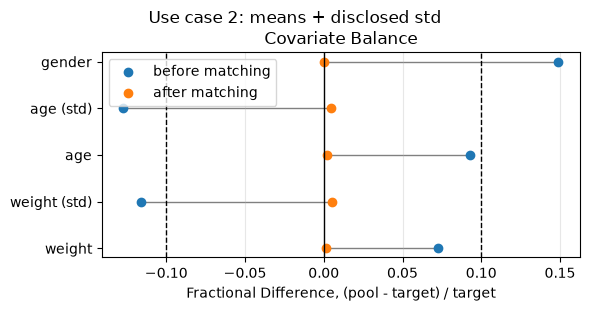

In [10]:
plot_fractional_difference(before_b, after_b)
plt.suptitle("Use case 2: means + disclosed std", y=1.02);

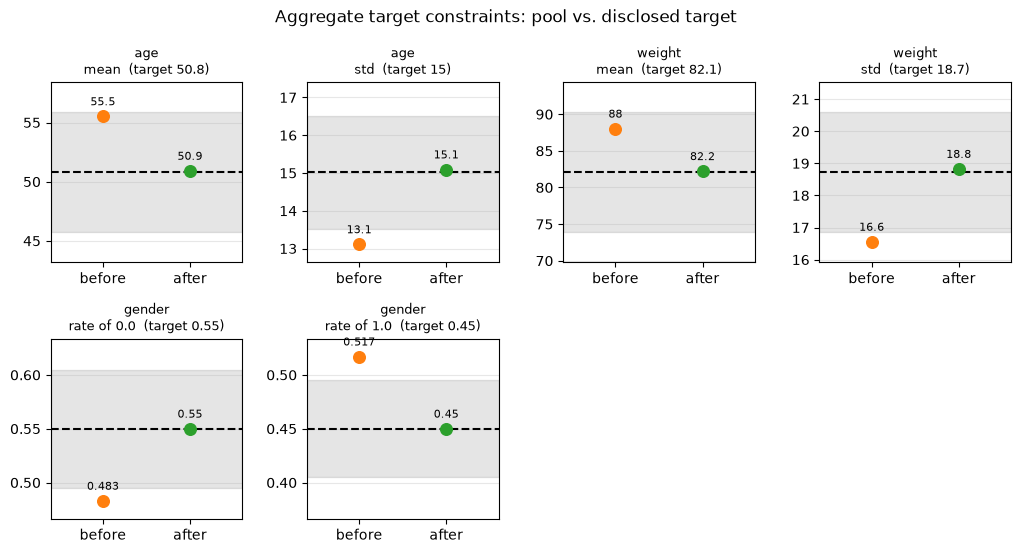

In [11]:
fig = plot_aggregate_target_match(before_b, after_b)

## 4. Use case 3 -- medians and quantiles instead of means

Published Table 1s often report a **median** ("age, median: 41") or other **quantiles** ("age, IQR:
35-52") instead of a mean for a skewed covariate. A **quantile** `(q, value)` means
P(raw <= value) = q, e.g. `(0.2, 70.0)` for "80% of patients weigh more than 70kg", and a median is
the single quantile 0.5: `{"age": {"median": 41.0}}` is exactly `{"age": {"quantile": [(0.5, 41.0)]}}`.
Either way the disclosed value is the cutpoint: the matcher dichotomizes the raw column there and
matches the resulting rate, so you never compute the 0/1 column yourself. Here `age` discloses its
quartiles (25th, 50th and 75th percentile) and `weight` only a median.

A target like this is easiest to keep in a file, and that is what `load_demo_aggregate_target` has
been reading all along. Here is the packaged `quantiles` file:

In [12]:
path = get_demo_aggregate_target_path("quantiles")
print(path, end="\n\n")
print(open(path).read())

/Users/gmema/src/matching-fork/venv/lib/python3.12/site-packages/pybalance/sim/data/aggregate_target_quantiles.csv

feature,statistic,parameter,value
,n,,100
age,quantile,0.25,41.37572755384545
age,median,,53.71747134991201
age,quantile,0.75,63.69799477706703
weight,median,,82.66384310636546
gender,rate,0.0,0.55
gender,rate,1.0,0.45



One row per disclosed statistic, in four columns:

| `statistic` | `feature` | `parameter` | `value` |
|---|---|---|---|
| `n` | blank | blank | the target's sample size (one row, required) |
| `mean`, `std`, `median`, `min`, `max` | numeric feature | blank | the statistic |
| `quantile` | numeric feature | the proportion `q` | the cutpoint, i.e. P(feature <= value) = q |
| `rate` | categoric feature | the category level | that level's rate (levels may be omitted) |

`AggregateTarget.from_csv(path)` reads it, so a published Table 1 can be transcribed into a
spreadsheet and loaded directly. `to_csv()` writes it:

In [13]:
# `to_csv()` writes the same format -- here, use case 1's hand-written target.
print(my_target.to_csv())

feature,statistic,parameter,value
,n,,250
age,mean,,64.0
weight,mean,,80.0
gender,rate,0,0.35
gender,rate,1,0.65



Now load the `quantiles` file with `AggregateTarget.from_csv` and match to it. This is exactly what
`load_demo_aggregate_target` does; point `from_csv` at your own file to use your own target.

In [14]:
target_c = AggregateTarget.from_csv(path)
display(target_c)
before_c, after_c = match_to(target_c)

feature,type,stat,value
age,numeric,quantile_0.25,41.375728
age,numeric,quantile_0.5,53.717471
age,numeric,quantile_0.75,63.697995
weight,numeric,quantile_0.5,82.663843
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000


Scaling features by factor 200.00 in order to use integer solver with <= 0.4082% loss.
Solving for match population with pool size = 100 and target size = 100 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 10 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Solving with 1 workers ...
Initial balance score: 0.1405
Solution 1, time = 0.00 m
Objective:	100.0
Balance (aggregate_beta):	0.0000
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Status = OPTIMAL
Number of solutions found: 1


The target has no means to compare against (`NaN`), so `describe()` alone cannot tell us whether the
quantiles matched. `aggregate_target_constraints` (and `plot_aggregate_target_match`) can: they report
each quantile as `P(x <= value)`, which should equal its disclosed `q` after matching. `describe()`
still shows how the means, stds and every undisclosed feature moved.

In [15]:
(
    before_c
        .describe(quantiles=[])
        .join(
            after_c.describe(quantiles=[]),
            rsuffix='_matched'
        )[['pool', 'pool_matched', 'target']]
)

pool  pool_matched  target
population size N     1000.000        100.00  100.00
gender          0.0      0.483          0.55    0.55
                1.0      0.517          0.45    0.45
country         1.0      0.108          0.12     NaN
                2        0.224          0.17     NaN
                3        0.274          0.34     NaN
                4        0.284          0.31     NaN
                5        0.110          0.06     NaN
age             mean    55.520         52.47     NaN
                std     13.110         14.42     NaN
weight          mean    88.020         83.12     NaN
                std     16.550         15.74     NaN
height          mean   160.310        158.44     NaN
                std     19.500         18.93     NaN

,feature,constraint,target,pool_before,pool_after
0,age,P(x <= 41.3757),0.25,0.164,0.25
1,age,P(x <= 53.7175),0.50,0.400,0.50
2,age,P(x <= 63.698),0.75,0.661,0.75
3,weight,P(x <= 82.6638),0.50,0.378,0.50
4,gender,rate of 0.0,0.55,0.483,0.55
5,gender,rate of 1.0,0.45,0.517,0.45


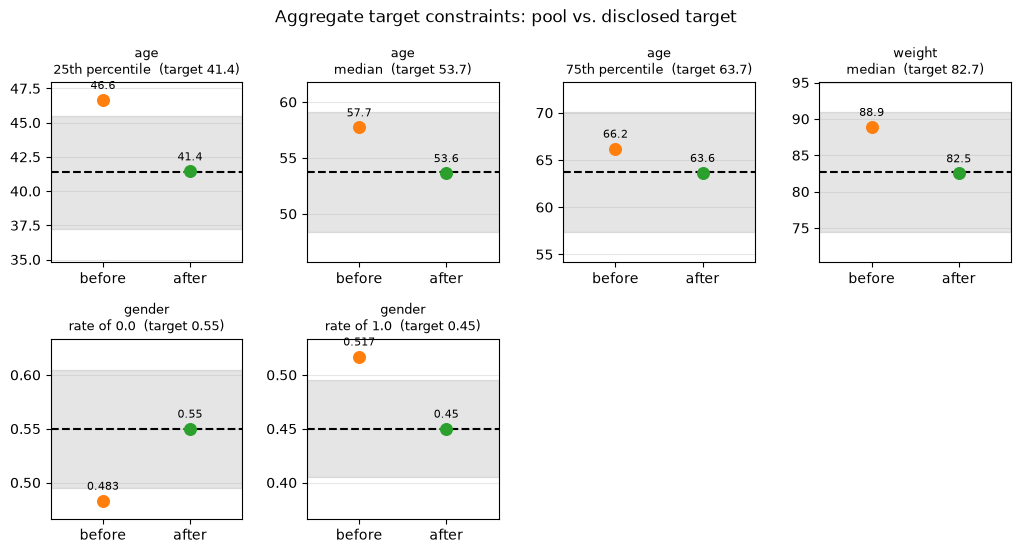

In [16]:
constraints = aggregate_target_constraints(before_c).merge(
    aggregate_target_constraints(after_c),
    on=["feature", "constraint", "target"],
    suffixes=("_before", "_after"),
)
display(constraints.round(3))

fig = plot_aggregate_target_match(before_c, after_c)

### A soft maximum

Trials also report ranges ("weight, max: 100"). `min` and `max` are simply the 0th and 100th
quantile, so they can be added to any numeric feature: `{"weight": {"median": 82.7, "max": 100.0}}`,
or a `min`/`max` row in the CSV. Like every other constraint they are **soft**: the matcher minimizes
the fraction of patients above `max` (below `min`) as part of its objective, trading it off against
the rest rather than enforcing a hard bound. A limit that no pool patient violates is simply
skipped.

Here we take use case 3's target and add a ceiling on `weight`:

In [17]:
numeric = {feature: dict(stats) for feature, stats in target_c.numeric.items()}
numeric["weight"]["max"] = 100.0  # soft ceiling: no patient heavier than 100kg

target_d = AggregateTarget(n=target_c.n, numeric=numeric, categoric=target_c.categoric)
display(target_d)
before_d, after_d = match_to(target_d)

feature,type,stat,value
age,numeric,quantile_0.25,41.375728
age,numeric,quantile_0.5,53.717471
age,numeric,quantile_0.75,63.697995
weight,numeric,quantile_0.5,82.663843
weight,numeric,max,100.000000
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000


Detected constant feature(s) in target population: weight_q1.0_0.0,weight_q1.0_1.0.
Scaling features by factor 200.00 in order to use integer solver with <= 0.4082% loss.
Solving for match population with pool size = 100 and target size = 100 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 12 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Solving with 1 workers ...
Initial balance score: 0.2187
Solution 1, time = 0.00 m
Objective:	100.0
Balance (aggregate_beta):	0.0000
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Status = OPTIMAL
Number of solutions found: 1


The table lists the `max` as `P(x <= 100) (max)` with a target of 1: after matching, (almost) every
patient should be at or below 100kg, while the quartiles and the median still land on their targets.
The plot shows the same thing in the feature's own units: it fixes each quantile (25th, 50th, 75th
percentile, max) and compares the pool's value of it before and after matching with the disclosed
one. (Pass `quantiles_as="proportion"` to `plot_aggregate_target_match` to fix the cutpoint instead and
plot the proportion, as in the table.) The solver may log a note that the target is constant for the
max constraint -- expected, as its target rate of patients above the max is exactly 0.

,feature,constraint,target,pool_before,pool_after
0,age,P(x <= 41.3757),0.25,0.164,0.25
1,age,P(x <= 53.7175),0.50,0.400,0.50
2,age,P(x <= 63.698),0.75,0.661,0.75
3,weight,P(x <= 82.6638),0.50,0.378,0.50
4,weight,P(x <= 100) (max),1.00,0.729,1.00
5,gender,rate of 0.0,0.55,0.483,0.55
6,gender,rate of 1.0,0.45,0.517,0.45


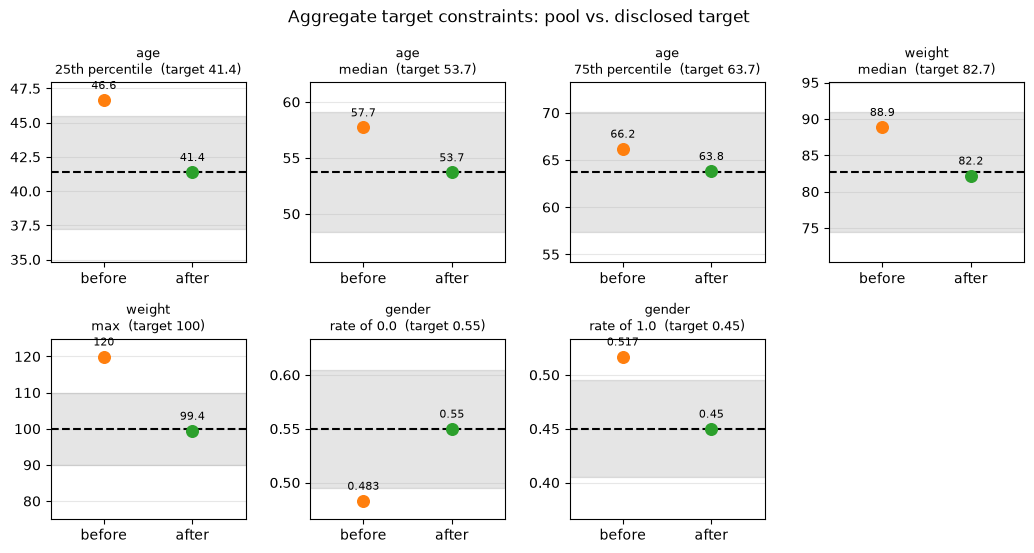

In [18]:
constraints = aggregate_target_constraints(before_d).merge(
    aggregate_target_constraints(after_d),
    on=["feature", "constraint", "target"],
    suffixes=("_before", "_after"),
)
display(constraints.round(3))

fig = plot_aggregate_target_match(before_d, after_d)

## Takeaways

- An `AggregateTarget` is the target's `n` plus whatever summary statistics are disclosed. Build one
  by hand, load it from the standard long-format CSV (`feature,statistic,parameter,value`) with
  `AggregateTarget.from_csv()`, write one with `to_csv()`, or use
  `pybalance.sim.load_demo_aggregate_target` / `generate_aggregate_target` for ready-made examples.
- Every disclosed statistic is its own constraint, and only disclosed statistics are constrained: a
  numeric feature needs at least one of **mean, std, median/quantile, min, max**, in any combination.
  A **std** adds a variance constraint the solver actually enforces (it's quadratic in the pool values
  but linear in the decision variables, so this is cheap for the CP-SAT solver); with a mean it is
  the spread around that mean, without one the spread around the matched subset's own mean.
- Features in the `MatchingData` headers that the target does not disclose are left unconstrained
  but still reported by `describe()`, so you can see how matching changed them.
- `AggregateTarget.categoric` rates can be **partially disclosed**: each disclosed level is a
  constraint and an omitted level simply has none.
- `AggregateConstraintSatisfactionMatcher` always uses `AggregateTargetBalanceCalculator` -- there's
  no `objective` to choose. `GeneticMatcher`, `PropensityScoreMatcher` and
  `ConstraintSatisfactionMatcher` also accept `objective="aggregate_beta"` (or a prebuilt
  `AggregateTargetBalanceCalculator` instance) directly, since they already accept any
  `BaseBalanceCalculator`.
- `EntropyBalanceWeighter`/`IPTWWeighter` are the remaining holdouts: they still hardcode the
  mean/std `"beta"` objective and don't yet build an `AggregateTargetBalanceCalculator`
  themselves. That's not silently wrong -- a target with a disclosed `median`/`quantile` makes
  `compute_aggregate_feature_moments` raise a clear error there today, rather than matching the
  wrong (raw, non-dichotomized) column.